In [9]:
from types import SimpleNamespace
 
from src.adata_processing import SingleAdataLoader
from src.stagm import STAGM

In [10]:
DATA_PATH = "Dataset/Xeniumranger_V1_hSkin_Melanoma_Add_on_FFPE_outs/"

In [11]:
loader = SingleAdataLoader(
    path=DATA_PATH,
    source="xenium",
    n_top_genes=100_000,
    n_neighbors=6, 
    image_emb=False,
    label=False,
    normalize=True,
)

In [12]:
adata = loader.run()
adata

Edge probabilities: 100%|██████████| 87499/87499 [00:00<00:00, 133838.03it/s]

adata load done


AnnData object with n_obs × n_vars = 87499 × 382
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'cell_labels'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'spatialdata_attrs', 'hvg', 'log1p'
    obsm: 'spatial', 'graph_neigh', 'feat', 'edge_probabilities'
    layers: None (.X)

In [13]:
config = SimpleNamespace(
    seed=39788,
    learning_rate=1e-3,
    num_hidden=64,
    num_proj_hidden=32,
    activation="relu",
    num_layers=2,
    drop_feature_rate_1=0.2,
    drop_feature_rate_2=0.2,
    tau=0.5,
    num_epochs=5,
    weight_decay=1e-5,
    num_clusters=8,
    num_gene=adata.obsm["feat"].shape[1],
    dropout=0.1,
    shuffle_ind=0,
    d_state=16,
    d_conv=4,
    order_by_degree=False,
    bidirectional=True,
    k=None,
)

# config = SimpleNamespace(
#     seed=39788,
#     learning_rate=0.0005,
#     num_hidden=64,
#     num_proj_hidden=64,
#     activation="prelu",
#     num_layers=1,
#     drop_feature_rate_1=0.1,
#     drop_feature_rate_2=0.2,
#     tau=65,
#     num_epochs=400,
#     weight_decay=1e-05,
#     num_clusters=7,
#     num_gene=3000,
#     num_neigh=6,
#     k=80,
#     dropout=0.0,
#     shuffle_ind=0,
#     d_state=16,
#     d_conv=4,
#     order_by_degree=True,
#     bidirectional=True
# )


args = SimpleNamespace(slide="xenium_sample", label=False)

In [14]:
model = STAGM(args, config, single=True, refine=True, checkpoint_path="xenium_model.pt")

In [15]:
model.adata = adata

In [17]:
model.train()

MemoryError: Unable to allocate 57.0 GiB for an array with shape (87499, 87499) and data type float64

In [ ]:
model.eva()

=== load ===

========== Model Diagnostics ==========
  Total parameters:     526,624
  Trainable parameters: 526,624
  Model weight size:    2.01 MB
  Peak GPU memory:      4686.61 MB
  Training time:        0m 12.4s  (12.4s total)
  Time per epoch:       2482.9 ms

  Loss curve:            first=9.0755  last=8.2820  min=8.2820  max=9.0755

  Embedding shape:      (87499, 64)
  Embedding norm — mean=8.0932  std=7.3615  min=1.0573  max=95.1557

embedding generated, go clustering


In [ ]:
model.cluster(args.label)

Searching resolution...
Cluster count 15 is too large, adjusting end downward...
resolution=0.1650, cluster number=10
resolution=0.1600, cluster number=10
resolution=0.1550, cluster number=10
resolution=0.1500, cluster number=9
resolution=0.1450, cluster number=9
resolution=0.1400, cluster number=9
resolution=0.1350, cluster number=10
resolution=0.1300, cluster number=10
resolution=0.1250, cluster number=7
resolution=0.1200, cluster number=8
resolution=0.1150, cluster number=8
resolution=0.1100, cluster number=9
resolution=0.1050, cluster number=7
resolution=0.1000, cluster number=7
resolution=0.0950, cluster number=7
resolution=0.0900, cluster number=7
resolution=0.0850, cluster number=7
resolution=0.0800, cluster number=6
Best resolution found: 0.1200
calculate SC and DB
SC: 0.15680381655693054
DB: 1.3882102514578618


In [ ]:
print(model.adata.obs["domain"].value_counts())
model.draw_xenium_spatial()

domain
3    22860
0    15839
1    14102
4    12990
2     7302
5     5941
7     4290
6     4175
Name: count, dtype: int64


KeyError: "Spatial key 'spatial' not found in `adata.uns`."

start umap


/workspace/src/stagm.py:490: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


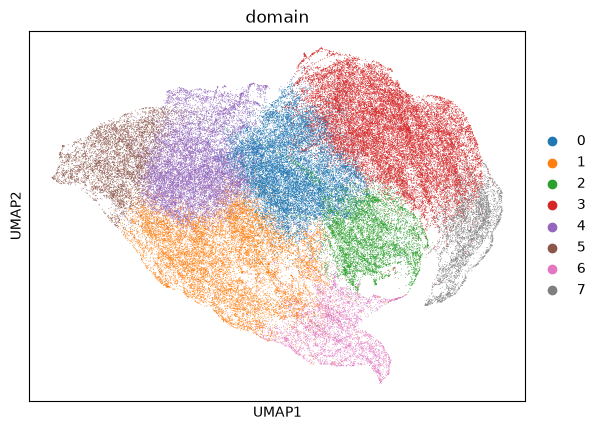

In [ ]:
model.draw_umap()